# Clasificador de huevos: `good` vs `crack`

Notebook educativo para Google Colab con GPU. Integra preprocesamiento digital, una red densa (MLP) y una red convolucional (CNN). El objetivo principal es minimizar los falsos negativos de la clase `crack`: un huevo agrietado clasificado como bueno es el error más costoso.

## Ruta de trabajo
1. Configurar Colab y GPU.
2. Descargar el dataset COCO desde Roboflow.
3. Recortar y estandarizar los huevos.
4. Entrenar MLP, CNN y una red con transfer learning (MobileNetV2).
5. Comparar desempeño y exportar el mejor modelo a Drive.

La API key se solicitará de forma oculta y no se guardará en el notebook.

In [ ]:
!pip -q install roboflow
print("Dependencias listas.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.3 MB/s eta 0:00:00
Dependencias listas.


In [ ]:
# Configuración base. Ejecutar en Google Colab.
import os
import json
import time
import shutil
import random
import warnings
from pathlib import Path
from getpass import getpass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from google.colab import drive
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
CLASS_NAMES = ['good', 'crack']
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Verificación explícita de GPU.
!nvidia-smi

Thu Sep 24 19:58:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# PEGA AQUÍ TU API KEY (se oculta y no queda escrita en el archivo).
# Se obtiene en: https://app.roboflow.com/settings/api
API_KEY = getpass('API key de Roboflow: ')
if not API_KEY.strip():
    raise ValueError('La API key no puede estar vacía.')
drive.mount('/content/drive')
DRIVE_DIR = Path('/content/drive/MyDrive/egg_quality')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

API key de Roboflow: ··········
Mounted at /content/drive


## 1. Descarga del dataset
Roboflow entrega las imágenes y las anotaciones COCO. Trabajaremos con las cajas delimitadoras para demostrar el recorte y la estandarización antes de entrenar.

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key=API_KEY)
project = rf.workspace('muhammad-fauzan-wbvuk').project('egg-pisqc')
versions = list(project.versions())
print('Versiones disponibles:', versions)
if not versions:
    raise RuntimeError('Roboflow no devolvió versiones para el proyecto.')
version_number = 1 if any(getattr(v, 'version', None) == 1 for v in versions) else getattr(versions[0], 'version', 1)
version = project.version(version_number)
dataset = version.download('coco')
DATASET_DIR = Path(dataset.location)
print('Dataset:', DATASET_DIR)
for path in sorted(DATASET_DIR.rglob('*')):
    if path.is_file():
        print(path.relative_to(DATASET_DIR))

loading Roboflow workspace...
loading Roboflow project...
Versiones disponibles: [<roboflow.core.version.Version object at 0x7ec5cedaeba0>, <roboflow.core.version.Version object at 0x7ec5d6eeafd0>]



Extracting Dataset Version Zip to egg-2 in coco:: 100%|██████████| 1227/1227 [00:00<00:00, 10469.02it/s]


Dataset: /content/egg-2
README.dataset.txt
README.roboflow.txt
train/2023-04-09-20_16_41-879723_jpg.rf.038c54d7a856a73ff288c1eef6448f79.jpg
train/2023-04-09-20_16_41-879723_jpg.rf.8f816616cb4650560bfb093eef26be66.jpg
train/2023-04-09-20_16_41-879723_jpg.rf.b4d955c5db8744ebf520e53f1d881614.jpg
train/2023-04-09-20_16_47-431319_jpg.rf.44d0d0ee2d7fad83f1078bd3429390c9.jpg
train/2023-04-09-20_16_47-431319_jpg.rf.467393a39e638b0fcc6bdf1562cc985d.jpg
train/2023-04-09-20_16_47-431319_jpg.rf.ba419e3f5500e4b171bc044cd4a4d915.jpg
train/2023-04-09-20_16_52-578705_jpg.rf.13389e9837c09b21e749bf95cf336658.jpg
train/2023-04-09-20_16_52-578705_jpg.rf.60e4d104cc660ab71c255681bcff89bb.jpg
train/2023-04-09-20_16_52-578705_jpg.rf.dfc624b467744806c7f96fc20372cbff.jpg
train/2023-04-09-20_17_08-764544_jpg.rf.3c8afe3fb2b78a73d464ee158d535e41.jpg
train/2023-04-09-20_17_08-764544_jpg.rf.545d6dadee6396c7de9ff1fed98f6377.jpg
train/2023-04-09-20_17_08-764544_jpg.rf.e6b210db604f1f83a7920b870ba9bf73.jpg
train/2023-04

## 2. Preprocesamiento por bounding box

Las imágenes se recortan alrededor del huevo, se añade un margen pequeño y se llevan a `100x100` píxeles. Esto reduce el costo computacional, elimina fondo irrelevante y entrega el mismo formato a ambos modelos. La normalización `/255` se hará al cargar los crops.

In [ ]:
def find_annotation_file(split_dir):
    files = list(split_dir.glob('_annotations.coco.json'))
    return files[0] if files else None

def find_image(images_dir, file_name):
    candidate = images_dir / file_name
    if candidate.exists():
        return candidate
    matches = list(images_dir.rglob(Path(file_name).name))
    return matches[0] if matches else None

def crop_from_bbox(image, bbox, margin=0.04):
    x, y, width, height = [float(value) for value in bbox]
    image_height, image_width = image.shape[:2]
    margin_x, margin_y = width * margin, height * margin
    x1 = max(0, int(x - margin_x))
    y1 = max(0, int(y - margin_y))
    x2 = min(image_width, int(x + width + margin_x))
    y2 = min(image_height, int(y + height + margin_y))
    crop = image[y1:y2, x1:x2]
    if crop.size == 0:
        return None
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    return cv2.resize(crop, IMG_SIZE, interpolation=cv2.INTER_AREA)

def process_split(split_name):
    split_dir = DATASET_DIR / split_name
    if not split_dir.exists():
        return 0
    annotation_path = find_annotation_file(split_dir)
    if annotation_path is None:
        print('Sin anotaciones COCO:', split_name)
        return 0
    with annotation_path.open(encoding='utf-8') as file:
        coco = json.load(file)
    print(split_name, '->', len(coco.get('images', [])), 'imágenes y', len(coco.get('annotations', [])), 'anotaciones')
    categories = {item['id']: item['name'].lower() for item in coco.get('categories', [])}
    images = {item['id']: item for item in coco.get('images', [])}
    output_count = 0
    for annotation in coco.get('annotations', []):
        label = categories.get(annotation['category_id'], '').lower()
        label = 'crack' if 'crack' in label else 'good' if 'good' in label else None
        image_info = images.get(annotation['image_id'])
        if label is None or image_info is None:
            continue
        image_path = find_image(split_dir, image_info['file_name'])
        if image_path is None:
            continue
        image = cv2.imread(str(image_path))
        crop = crop_from_bbox(image, annotation['bbox'])
        if crop is None:
            continue
        output_dir = Path('/content/crops') / split_name / label
        output_dir.mkdir(parents=True, exist_ok=True)
        output_path = output_dir / f"{Path(image_info['file_name']).stem}_{annotation['id']}.jpg"
        cv2.imwrite(str(output_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 95])
        output_count += 1
    return output_count

counts = {split: process_split(split) for split in ['train', 'valid', 'test']}
print('Crops generados:', counts)

train -> 1223 imágenes y 1238 anotaciones
Crops generados: {'train': 1238, 'valid': 0, 'test': 0}


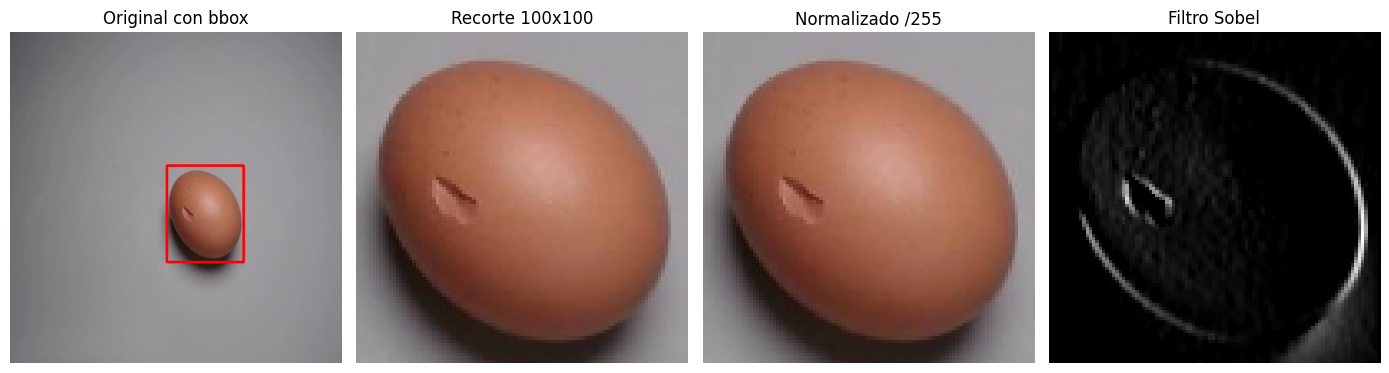

In [ ]:
# Inspección visual: bbox original, recorte, normalización y Sobel.
def first_example(split='train', label='crack'):
    split_dir = DATASET_DIR / split
    annotation_path = find_annotation_file(split_dir)
    with annotation_path.open(encoding='utf-8') as file:
        coco = json.load(file)
    categories = {item['id']: item['name'].lower() for item in coco['categories']}
    images = {item['id']: item for item in coco['images']}
    for annotation in coco['annotations']:
        current = categories.get(annotation['category_id'], '')
        if label in current:
            info = images[annotation['image_id']]
            path = find_image(split_dir, info['file_name'])
            image_bgr = cv2.imread(str(path))
            image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
            x, y, width, height = map(int, annotation['bbox'])
            boxed = image_rgb.copy()
            cv2.rectangle(boxed, (x, y), (x + width, y + height), (255, 0, 0), 3)
            crop = crop_from_bbox(image_bgr, annotation['bbox'])
            gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
            sobel = cv2.filter2D(gray, -1, np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32))
            return boxed, crop, crop.astype(np.float32) / 255.0, sobel
    return None

example = first_example()
if example:
    titles = ['Original con bbox', 'Recorte 100x100', 'Normalizado /255', 'Filtro Sobel']
    plt.figure(figsize=(14, 4))
    for index, (title, image) in enumerate(zip(titles, example), 1):
        plt.subplot(1, 4, index)
        plt.imshow(image, cmap='gray' if index == 4 else None)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

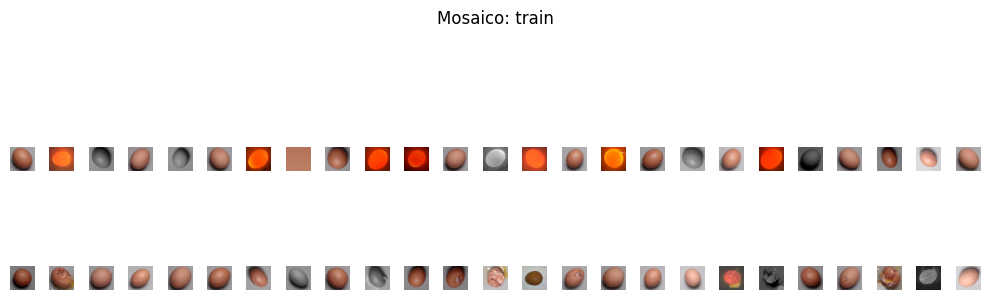

clase,crack,good
split,,
test,0,0
train,641,597
valid,0,0


Si hay un desbalance importante, se puede usar class_weight o augmentation dirigida a la clase minoritaria.


In [ ]:
# Mosaico de ejemplos y balance por split.
def show_mosaic(split='train', per_class=25):
    plt.figure(figsize=(10, 4))
    for row, label in enumerate(CLASS_NAMES):
        files = list((Path('/content/crops') / split / label).glob('*.jpg'))[:per_class]
        for column, path in enumerate(files):
            image = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
            axis = plt.subplot(2, per_class, row * per_class + column + 1)
            axis.imshow(image)
            axis.axis('off')
            if column == 0:
                axis.set_ylabel(label)
    plt.suptitle(f'Mosaico: {split}')
    plt.tight_layout()
    plt.show()

show_mosaic()
balance = []
for split in ['train', 'valid', 'test']:
    for label in CLASS_NAMES:
        balance.append({'split': split, 'clase': label, 'imagenes': len(list((Path('/content/crops') / split / label).glob('*.jpg')))})
balance_df = pd.DataFrame(balance)
display(balance_df.pivot(index='split', columns='clase', values='imagenes'))
print('Si hay un desbalance importante, se puede usar class_weight o augmentation dirigida a la clase minoritaria.')

## 3. Carga, normalización y augmentation
`image_dataset_from_directory` produce etiquetas enteras, por eso usaremos `sparse_categorical_crossentropy`. `prefetch` solapa la preparación de lotes con el entrenamiento. La augmentation agrega variaciones pequeñas para combatir el sobreajuste con un dataset reducido.

In [ ]:
from pathlib import Path

print("Dataset original:")
for p in DATASET_DIR.iterdir():
    print("-", p.name)

print("\nCrops generados:")
crops_dir = Path("/content/crops")
if crops_dir.exists():
    for p in crops_dir.iterdir():
        print("-", p.name)

Dataset original:
- README.roboflow.txt
- README.dataset.txt
- train

Crops generados:
- train


In [ ]:
from pathlib import Path
import shutil
import random

random.seed(42)

CROPS_DIR = Path("/content/crops")
TRAIN_DIR = CROPS_DIR / "train"

# Guardamos la carpeta original con todos los crops
ALL_DIR = CROPS_DIR / "all"

if not ALL_DIR.exists():
    TRAIN_DIR.rename(ALL_DIR)

# Identificar la imagen original de la que salió cada crop
# Los nombres tienen formato: nombre_imagen_IDANOTACION.jpg
groups = {}

for label in ["good", "crack"]:
    label_dir = ALL_DIR / label

    for file in label_dir.glob("*.jpg"):
        original_image = file.stem.rsplit("_", 1)[0]

        if original_image not in groups:
            groups[original_image] = []

        groups[original_image].append((file, label))

# Dividir POR IMAGEN ORIGINAL para evitar data leakage
image_groups = list(groups.keys())
random.shuffle(image_groups)

n = len(image_groups)

train_end = int(n * 0.80)
valid_end = int(n * 0.90)

split_groups = {
    "train": image_groups[:train_end],
    "valid": image_groups[train_end:valid_end],
    "test": image_groups[valid_end:]
}

# Crear carpetas
for split in ["train", "valid", "test"]:
    for label in ["good", "crack"]:
        (CROPS_DIR / split / label).mkdir(parents=True, exist_ok=True)

# Copiar crops respetando la división por imagen original
for split, group_names in split_groups.items():

    for group_name in group_names:

        for source_file, label in groups[group_name]:

            destination = CROPS_DIR / split / label / source_file.name
            shutil.copy2(source_file, destination)

print("División completada.\n")

for split in ["train", "valid", "test"]:

    good = len(list((CROPS_DIR / split / "good").glob("*.jpg")))
    crack = len(list((CROPS_DIR / split / "crack").glob("*.jpg")))

    print(
        f"{split}: "
        f"good={good}, "
        f"crack={crack}, "
        f"total={good + crack}"
    )

División completada.

train: good=468, crack=521, total=989
valid: good=65, crack=58, total=123
test: good=64, crack=62, total=126


In [19]:
def load_split(split, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        COMBINED_DIR / split,
        labels='inferred',
        label_mode='int',
        class_names=CLASS_NAMES,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

train_raw = load_split('train', True)
valid_raw = load_split('valid', False)
test_raw = load_split('test', False)

normalization = tf.keras.layers.Rescaling(1.0 / 255)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
], name='augmentation')

AUTOTUNE = tf.data.AUTOTUNE

def preprocess_train(images, labels):
    return augmentation(normalization(images)), labels

def preprocess_eval(images, labels):
    return normalization(images), labels

train_ds = train_raw.map(
    preprocess_train,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

valid_ds = valid_raw.map(
    preprocess_eval,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

test_ds = test_raw.map(
    preprocess_eval,
    num_parallel_calls=AUTOTUNE
).prefetch(AUTOTUNE)

Found 1765 files belonging to 2 classes.
Found 251 files belonging to 2 classes.
Found 233 files belonging to 2 classes.


## 4. Modelo MLP
`Flatten` convierte cada imagen en un vector. Las capas densas aprenden combinaciones globales de píxeles; ReLU se usa en las capas ocultas y softmax entrega una probabilidad por clase.

## 5. Modelo CNN
Las convoluciones detectan bordes y patrones locales reutilizando filtros. MaxPooling reduce la resolución conservando señales dominantes. Dropout apaga unidades durante el entrenamiento y ayuda a limitar el sobreajuste.

## 5b. Transfer learning: MobileNetV2
Con solo ~408 imágenes, entrenar una CNN desde cero es frágil. El **transfer learning** reutiliza una red ya entrenada en millones de fotos (ImageNet), congela sus capas de extracción de features y solo entrena la cabeza clasificadora. Casi siempre supera a una CNN desde cero con pocos datos y es la práctica estándar en producción.

In [20]:
# Configuración de ambos modelos y su entrenamiento.
# Callbacks compartidos: EarlyStopping (evita sobreajuste), ReduceLROnPlateau
# (afina cuando la pérdida se estanca) y ModelCheckpoint (guarda mejor val_loss).
def callbacks_for(path):
    return [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
        tf.keras.callbacks.ModelCheckpoint(path, monitor='val_loss', save_best_only=True),
    ]

# Modelo 1: red densa (MLP). Flatten pasa la imagen (100x100x3) a un vector;
# las capas densas aprenden combinaciones globales de píxeles. Es la línea base
# (una imagen de 30.000 valores no debería clasificarse con densas puras).
mlp = tf.keras.Sequential([
    tf.keras.Input(shape=(*IMG_SIZE, 3)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax'),
], name='mlp')
mlp.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp.summary()

# Modelo 2: CNN. Las convoluciones detectan bordes y patrones locales reutilizando
# filtros; MaxPooling reduce la resolución conservando las señales dominantes;
# Dropout apaga unidades al azar y reduce el sobreajuste (408 imágenes es poco).
cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(*IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(2, activation='softmax'),
], name='cnn')
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

# Entrenamiento con medición de tiempo. El profe valora el PORQUÉ, no solo el qué:
# la CNN puede tardar más por época, pero con menos parámetros por patrón local.
EPOCHS = 50

start_mlp = time.time()
history_mlp = mlp.fit(
    train_ds, validation_data=valid_ds, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for('/content/mejor_mlp_v2.keras'), verbose=1,
)
elapsed_mlp = time.time() - start_mlp
print(f'MLP entrenado en {elapsed_mlp:.1f} s')

start_cnn = time.time()
history_cnn = cnn.fit(
    train_ds, validation_data=valid_ds, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for('/content/mejor_cnn_v2.keras'), verbose=1,
)
elapsed_cnn = time.time() - start_cnn
print(f'CNN entrenada en {elapsed_cnn:.1f} s')

# Modelo 3: Transfer learning con MobileNetV2 (pre-entrenada en ImageNet).
# Con solo 408 imágenes, reutilizar pesos ya aprendidos en millones de fotos
# casi siempre gana a entrenar una CNN desde cero. Congelamos el extractor de
# características y entrenamos solo la cabeza densa (fine-tuning opcional).
# La primera capa Rescaling pasa de [0,1] a [-1,1] (preprocesamiento de MobileNetV2)
# para que el contrato de datos (0-1) se mantenga igual en los 3 modelos.
base_mobilenet = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=(*IMG_SIZE, 3))
base_mobilenet.trainable = False  # transfer learning: pesos congelados
mobilenet = tf.keras.Sequential([
    tf.keras.Input(shape=(*IMG_SIZE, 3)),
    tf.keras.layers.Rescaling(2.0, offset=-1.0),  # [0,1] -> [-1,1]
    base_mobilenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(2, activation='softmax'),
], name='mobilenetv2')
mobilenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mobilenet.summary()

start_mobilenet = time.time()
history_mobilenet = mobilenet.fit(
    train_ds, validation_data=valid_ds, epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=callbacks_for('/content/mejor_mobilenet_v2.keras'), verbose=1,
)
elapsed_mobilenet = time.time() - start_mobilenet
print(f'MobileNetV2 (transfer learning) entrenada en {elapsed_mobilenet:.1f} s')


Model: "mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,840,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,850,530 (14.69 MB)

 Trainable params: 3,850,530 (14.69 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,098 (8.93 MB)

 Trainable params: 82,114 (320.76 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 46s 531ms/step - accuracy: 0.7785 - loss: 0.5113 - val_accuracy: 0.9163 - val_loss: 0.2224 - learning_rate: 0.0010
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.8589 - loss: 0.3218 - val_accuracy: 0.9283 - val_loss: 0.1878 - learning_rate: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8827 - loss: 0.2630 - val_accuracy: 0.8964 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8980 - loss: 0.2409 - val_accuracy: 0.8884 - val_loss: 0.1988 - learning_rate: 0.0010
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.9144 - loss: 0.2129 - val_accuracy: 0.9203 - val_loss: 0.1709 - learning_rate: 3.0000e-04
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.9088 - loss: 0.2097 - val_accuracy: 0.9084 - val_loss: 0.1666 - learning_rate: 3.0000e-04
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9178 - loss: 0.2015

## 6. Evaluación comparativa
Se comparan accuracy y **recall de `crack`**: un huevo agrietado que pasa por bueno
es el error más caro del negocio, por eso el recall de `crack` manda en la decisión final.


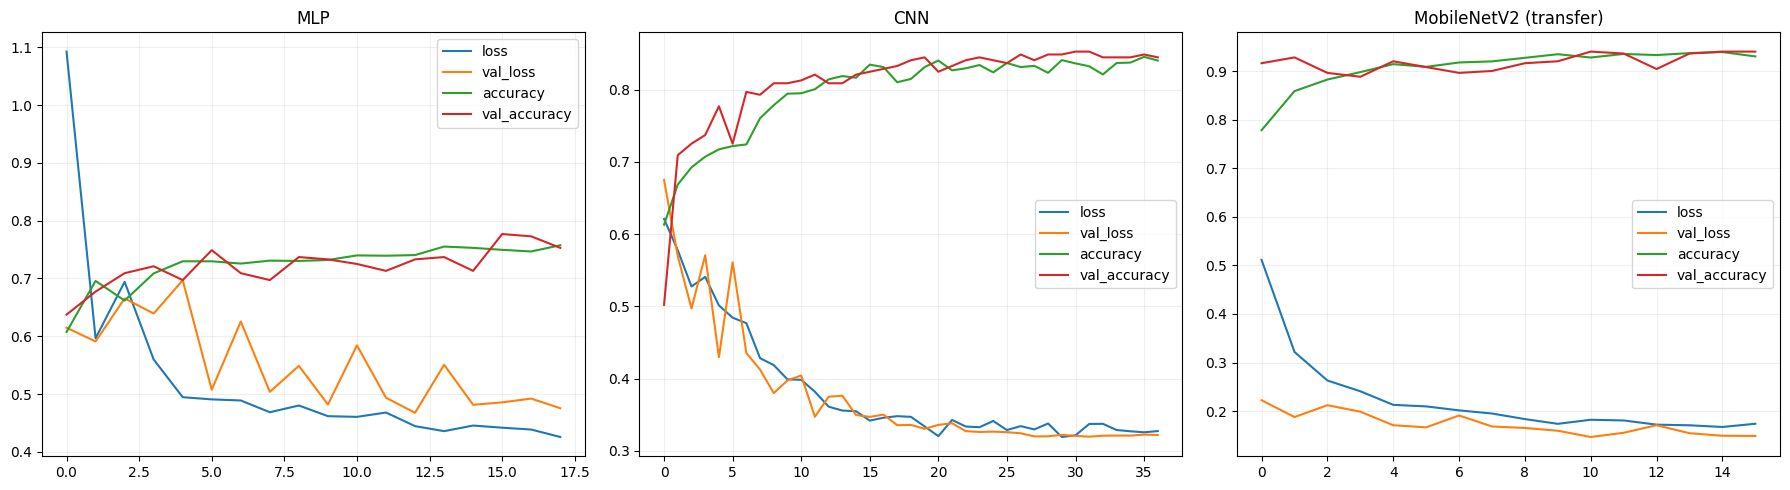


=== MLP ===
loss=0.5826 accuracy=0.6738 recall_crack=0.6434 tiempo=84.3s
              precision    recall  f1-score   support

        good       0.62      0.71      0.66       104
       crack       0.73      0.64      0.69       129

    accuracy                           0.67       233
   macro avg       0.68      0.68      0.67       233
weighted avg       0.68      0.67      0.67       233



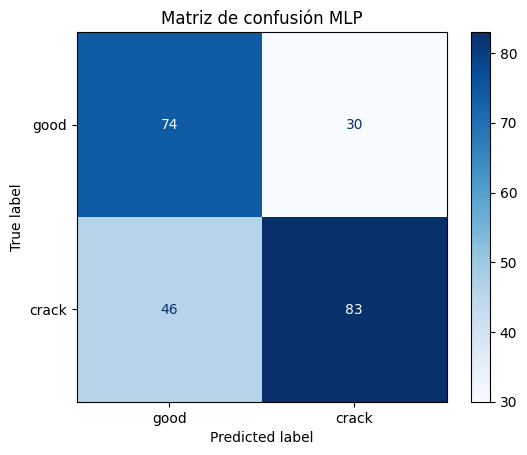


=== CNN ===
loss=0.4548 accuracy=0.8026 recall_crack=0.7752 tiempo=165.8s
              precision    recall  f1-score   support

        good       0.75      0.84      0.79       104
       crack       0.85      0.78      0.81       129

    accuracy                           0.80       233
   macro avg       0.80      0.81      0.80       233
weighted avg       0.81      0.80      0.80       233



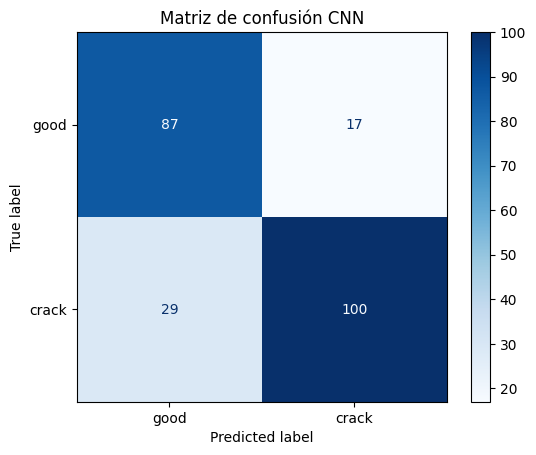


=== MobileNetV2 ===
loss=0.3854 accuracy=0.8670 recall_crack=0.8760 tiempo=110.7s
              precision    recall  f1-score   support

        good       0.85      0.86      0.85       104
       crack       0.88      0.88      0.88       129

    accuracy                           0.87       233
   macro avg       0.87      0.87      0.87       233
weighted avg       0.87      0.87      0.87       233



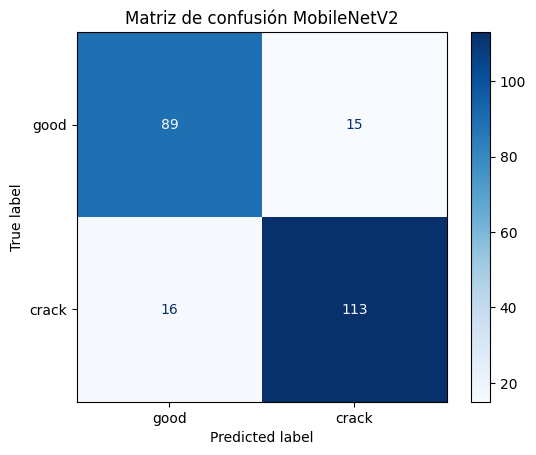

In [21]:
def plot_history(history, title):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.plot(history.history['accuracy'], label='accuracy')
    plt.plot(history.history['val_accuracy'], label='val_accuracy')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.2)

plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plot_history(history_mlp, 'MLP')
plt.subplot(1, 3, 2)
plot_history(history_cnn, 'CNN')
plt.subplot(1, 3, 3)
plot_history(history_mobilenet, 'MobileNetV2 (transfer)')
plt.tight_layout()
plt.show()

def evaluate_model(model, name, elapsed):
    loss, accuracy = model.evaluate(test_ds, verbose=0)
    y_true = np.concatenate([labels.numpy() for _, labels in test_ds])
    probabilities = model.predict(test_ds, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    recall_crack = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f'\n=== {name} ===')
    print(f'loss={loss:.4f} accuracy={accuracy:.4f} recall_crack={recall_crack:.4f} tiempo={elapsed:.1f}s')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de confusión {name}')
    plt.show()
    return [{'accuracy': float(accuracy), 'recall_crack': float(recall_crack),
             'elapsed_s': float(elapsed), 'y_true': y_true, 'y_pred': y_pred}]

mlp_result = evaluate_model(mlp, 'MLP', elapsed_mlp)
cnn_result = evaluate_model(cnn, 'CNN', elapsed_cnn)
mobilenet_result = evaluate_model(mobilenet, 'MobileNetV2', elapsed_mobilenet)


Mejor modelo: MobileNetV2 (recall_crack=0.8760)


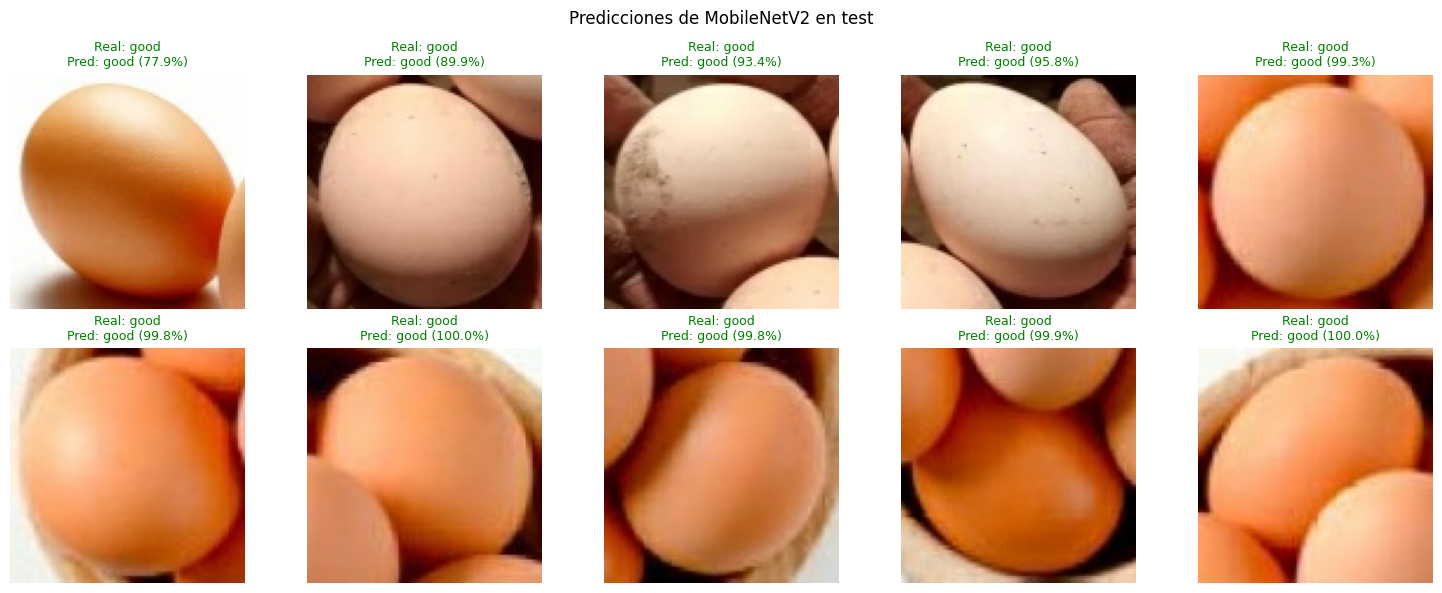

,modelo,accuracy,recall_crack,tiempo_s
0,MLP,0.673820,0.643411,84.258291
1,CNN,0.802575,0.775194,165.817634
2,MobileNetV2,0.866953,0.875969,110.697766


In [22]:
# Se elige el modelo con mayor recall de crack (el error caro es el huevo roto que pasa por bueno).
results = {
    'MLP': mlp_result[0],
    'CNN': cnn_result[0],
    'MobileNetV2': mobilenet_result[0],
}
models = {'MLP': mlp, 'CNN': cnn, 'MobileNetV2': mobilenet}
best_name = max(results, key=lambda k: results[k]['recall_crack'])
best_model = models[best_name]
best_recall = results[best_name]['recall_crack']
print(f'Mejor modelo: {best_name} (recall_crack={best_recall:.4f})')

images, labels_batch = next(iter(test_ds))
predictions = best_model.predict(images, verbose=0)
plt.figure(figsize=(15, 6))
for index in range(min(10, len(images))):
    predicted = int(predictions[index].argmax())
    actual = int(labels_batch[index])
    color = 'green' if predicted == actual else 'red'
    plt.subplot(2, 5, index + 1)
    plt.imshow((images[index].numpy() * 255).astype('uint8'))
    plt.title(f'Real: {CLASS_NAMES[actual]}\nPred: {CLASS_NAMES[predicted]} ({predictions[index][predicted]:.1%})', color=color, fontsize=9)
    plt.axis('off')
plt.suptitle(f'Predicciones de {best_name} en test')
plt.tight_layout()
plt.show()

# Tabla comparativa final: justifica QUÉ modelo gana y POR QUÉ.
comparison = pd.DataFrame({
    'modelo': list(results.keys()),
    'accuracy': [results[k]['accuracy'] for k in results],
    'recall_crack': [results[k]['recall_crack'] for k in results],
    'tiempo_s': [results[k]['elapsed_s'] for k in results],
})
display(comparison)


In [23]:
print(best_name)

MobileNetV2


In [24]:
from pathlib import Path

print(Path('/content/mejor_mobilenet_v2.keras').exists())

True


In [25]:
# ============================================
# PERSISTENCIA V2
# Dataset combinado + MobileNetV2
# ============================================

import json
import shutil
from pathlib import Path

# Aseguramos carpeta de Drive
DRIVE_DIR = Path('/content/drive/MyDrive/egg_quality')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoints de la segunda ronda de entrenamiento
best_path = {
    'MLP': '/content/mejor_mlp_v2.keras',
    'CNN': '/content/mejor_cnn_v2.keras',
    'MobileNetV2': '/content/mejor_mobilenet_v2.keras'
}[best_name]

print("Ganador:", best_name)
print("Checkpoint:", best_path)

if not Path(best_path).exists():
    raise FileNotFoundError(
        f"No se encontró el modelo ganador en: {best_path}"
    )

# Carpeta independiente para no pisar la V1
export_dir = DRIVE_DIR / 'models_v2'

# Si vuelves a ejecutar esta celda, limpiamos SOLO la V2
if export_dir.exists():
    shutil.rmtree(export_dir)

export_dir.mkdir(parents=True, exist_ok=True)

# Copiar modelo ganador
model_output = export_dir / Path(best_path).name
shutil.copy2(best_path, model_output)

# Clases
with (export_dir / 'clases.json').open(
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        CLASS_NAMES,
        file,
        ensure_ascii=False,
        indent=2
    )

# Contrato de preprocesamiento
preprocessing = {
    'crop_size': [100, 100],
    'scale': '/255',
    'color_format': 'RGB',
    'bbox_margin': 0.04,
    'version': 'v2',
    'dataset': 'combined',
    'winner': best_name
}

with (export_dir / 'preprocesamiento.json').open(
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        preprocessing,
        file,
        ensure_ascii=False,
        indent=2
    )

# Guardar también métricas de la V2
metrics = {
    model_name: {
        'accuracy': float(results[model_name]['accuracy']),
        'recall_crack': float(results[model_name]['recall_crack']),
        'elapsed_s': float(results[model_name]['elapsed_s'])
    }
    for model_name in results
}

with (export_dir / 'metricas.json').open(
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        metrics,
        file,
        ensure_ascii=False,
        indent=2
    )

# Crear ZIP V2
zip_base = '/content/egg_quality_models_v2'

zip_path = shutil.make_archive(
    zip_base,
    'zip',
    export_dir
)

# Guardarlo en Drive sin reemplazar la V1
drive_zip = DRIVE_DIR / 'egg_quality_models_v2.zip'

if drive_zip.exists():
    drive_zip.unlink()

shutil.copy2(
    zip_path,
    drive_zip
)

print("\n✅ Persistencia V2 completada")
print("Modelo ganador:", best_name)
print("Modelo:", model_output)
print("Carpeta:", export_dir)
print("ZIP:", drive_zip)

Ganador: MobileNetV2
Checkpoint: /content/mejor_mobilenet_v2.keras

✅ Persistencia V2 completada
Modelo ganador: MobileNetV2
Modelo: /content/drive/MyDrive/egg_quality/models_v2/mejor_mobilenet_v2.keras
Carpeta: /content/drive/MyDrive/egg_quality/models_v2
ZIP: /content/drive/MyDrive/egg_quality/egg_quality_models_v2.zip


In [26]:
from pathlib import Path

print("Drive montado:", Path("/content/drive/MyDrive").exists())
print("MobileNet V2 existe:", Path("/content/mejor_mobilenet_v2.keras").exists())

DRIVE_DIR = Path("/content/drive/MyDrive/egg_quality")

print("\nContenido actual de egg_quality:")
if DRIVE_DIR.exists():
    for p in DRIVE_DIR.iterdir():
        print("-", p.name)
else:
    print("No existe la carpeta.")


Drive montado: True
MobileNet V2 existe: True

Contenido actual de egg_quality:
- models_v2
- egg_quality_models_v2.zip


In [27]:
from google.colab import drive
from pathlib import Path
import shutil
import json

# Montar Drive otra vez por seguridad
drive.mount('/content/drive')

DRIVE_DIR = Path("/content/drive/MyDrive/egg_quality")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = Path("/content/mejor_mobilenet_v2.keras")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No existe el modelo: {MODEL_PATH}"
    )

# Carpeta exclusiva de V2
EXPORT_DIR = DRIVE_DIR / "models_v2"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copiar MobileNetV2
shutil.copy2(
    MODEL_PATH,
    EXPORT_DIR / "mejor_mobilenet_v2.keras"
)

# Guardar clases
with (EXPORT_DIR / "clases.json").open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        CLASS_NAMES,
        f,
        ensure_ascii=False,
        indent=2
    )

# Guardar preprocesamiento
preprocessing = {
    "crop_size": [100, 100],
    "scale": "/255",
    "color_format": "RGB",
    "bbox_margin": 0.04,
    "version": "v2",
    "dataset": "combined",
    "winner": "MobileNetV2"
}

with (EXPORT_DIR / "preprocesamiento.json").open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing,
        f,
        ensure_ascii=False,
        indent=2
    )

# Crear ZIP
zip_base = "/content/egg_quality_models_v2"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    EXPORT_DIR
)

DEST_ZIP = DRIVE_DIR / "egg_quality_models_v2.zip"

shutil.copy2(
    zip_path,
    DEST_ZIP
)

print("✅ GUARDADO")
print("Modelo:", EXPORT_DIR / "mejor_mobilenet_v2.keras")
print("ZIP:", DEST_ZIP)
print("\nContenido de Drive:")

for p in DRIVE_DIR.iterdir():
    print("-", p.name)

ValueError: Mountpoint must not already contain files

In [28]:
from pathlib import Path
import shutil
import json

# Drive YA está montado
DRIVE_DIR = Path("/content/drive/MyDrive/egg_quality")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = Path("/content/mejor_mobilenet_v2.keras")

print("Modelo existe:", MODEL_PATH.exists())
print("Drive existe:", DRIVE_DIR.exists())

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"No existe el modelo: {MODEL_PATH}"
    )

# Carpeta V2
EXPORT_DIR = DRIVE_DIR / "models_v2"

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copiar modelo ganador
shutil.copy2(
    MODEL_PATH,
    EXPORT_DIR / "mejor_mobilenet_v2.keras"
)

# Clases
with (EXPORT_DIR / "clases.json").open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        CLASS_NAMES,
        f,
        ensure_ascii=False,
        indent=2
    )

# Preprocesamiento
preprocessing = {
    "crop_size": [100, 100],
    "scale": "/255",
    "color_format": "RGB",
    "bbox_margin": 0.04,
    "version": "v2",
    "dataset": "combined",
    "winner": "MobileNetV2"
}

with (EXPORT_DIR / "preprocesamiento.json").open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing,
        f,
        ensure_ascii=False,
        indent=2
    )

# Métricas
metrics = {
    model_name: {
        "accuracy": float(results[model_name]["accuracy"]),
        "recall_crack": float(results[model_name]["recall_crack"]),
        "elapsed_s": float(results[model_name]["elapsed_s"])
    }
    for model_name in results
}

with (EXPORT_DIR / "metricas.json").open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

# Crear ZIP
zip_base = "/content/egg_quality_models_v2"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    EXPORT_DIR
)

DEST_ZIP = DRIVE_DIR / "egg_quality_models_v2.zip"

if DEST_ZIP.exists():
    DEST_ZIP.unlink()

shutil.copy2(
    zip_path,
    DEST_ZIP
)

print("\n✅ GUARDADO CORRECTAMENTE")
print("Modelo:", EXPORT_DIR / "mejor_mobilenet_v2.keras")
print("ZIP:", DEST_ZIP)

print("\nContenido de egg_quality:")
for p in DRIVE_DIR.iterdir():
    print("-", p.name)

Modelo existe: True
Drive existe: True

✅ GUARDADO CORRECTAMENTE
Modelo: /content/drive/MyDrive/egg_quality/models_v2/mejor_mobilenet_v2.keras
ZIP: /content/drive/MyDrive/egg_quality/egg_quality_models_v2.zip

Contenido de egg_quality:
- models_v2
- egg_quality_models_v2.zip


In [29]:
from pathlib import Path
import shutil
import json
import os

# Modelo ya entrenado
MODEL_PATH = Path("/content/mejor_mobilenet_v2.keras")

if not MODEL_PATH.exists():
    raise FileNotFoundError("No encuentro /content/mejor_mobilenet_v2.keras")

# NUEVA carpeta directamente en Mi unidad
SAVE_DIR = Path("/content/drive/MyDrive/HUEVOS_MODELO_V2")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Guardando en:", SAVE_DIR)

# 1. Copiar modelo
MODEL_DEST = SAVE_DIR / "mejor_mobilenet_v2.keras"
shutil.copy2(MODEL_PATH, MODEL_DEST)

# 2. Clases
with (SAVE_DIR / "clases.json").open("w", encoding="utf-8") as f:
    json.dump(
        CLASS_NAMES,
        f,
        ensure_ascii=False,
        indent=2
    )

# 3. Preprocesamiento
preprocessing = {
    "crop_size": [100, 100],
    "scale": "/255",
    "color_format": "RGB",
    "bbox_margin": 0.04,
    "version": "v2",
    "dataset": "dataset combinado",
    "winner": "MobileNetV2"
}

with (SAVE_DIR / "preprocesamiento.json").open("w", encoding="utf-8") as f:
    json.dump(
        preprocessing,
        f,
        ensure_ascii=False,
        indent=2
    )

# 4. Métricas
metrics = {
    model_name: {
        "accuracy": float(results[model_name]["accuracy"]),
        "recall_crack": float(results[model_name]["recall_crack"]),
        "elapsed_s": float(results[model_name]["elapsed_s"])
    }
    for model_name in results
}

with (SAVE_DIR / "metricas.json").open("w", encoding="utf-8") as f:
    json.dump(
        metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

# 5. Archivo de comprobación
with (SAVE_DIR / "GUARDADO_CORRECTAMENTE.txt").open("w", encoding="utf-8") as f:
    f.write(
        "Modelo V2 de clasificación de huevos\n"
        "Ganador: MobileNetV2\n"
        "Dataset combinado\n"
    )

# 6. Crear ZIP FUERA de la carpeta y copiarlo a Drive
ZIP_TEMP = shutil.make_archive(
    "/content/HUEVOS_MODELO_V2",
    "zip",
    SAVE_DIR
)

ZIP_DEST = Path("/content/drive/MyDrive/HUEVOS_MODELO_V2.zip")

if ZIP_DEST.exists():
    ZIP_DEST.unlink()

shutil.copy2(ZIP_TEMP, ZIP_DEST)

# Forzar escritura pendiente
os.sync()

print("\n✅ TODO GUARDADO")

print("\nCarpeta:")
print(SAVE_DIR)

print("\nZIP:")
print(ZIP_DEST)

print("\nArchivos:")
for p in SAVE_DIR.iterdir():
    print(
        "-",
        p.name,
        round(p.stat().st_size / (1024 * 1024), 2),
        "MB"
    )

print("\nZIP existe:", ZIP_DEST.exists())
print(
    "Tamaño ZIP:",
    round(ZIP_DEST.stat().st_size / (1024 * 1024), 2),
    "MB"
)

Guardando en: /content/drive/MyDrive/HUEVOS_MODELO_V2

✅ TODO GUARDADO

Carpeta:
/content/drive/MyDrive/HUEVOS_MODELO_V2

ZIP:
/content/drive/MyDrive/HUEVOS_MODELO_V2.zip

Archivos:
- preprocesamiento.json 0.0 MB
- clases.json 0.0 MB
- metricas.json 0.0 MB
- mejor_mobilenet_v2.keras 10.12 MB
- GUARDADO_CORRECTAMENTE.txt 0.0 MB

ZIP existe: True
Tamaño ZIP: 8.93 MB


In [30]:
!ls -lah "/content/drive/MyDrive/HUEVOS_MODELO_V2"
!ls -lh "/content/drive/MyDrive/HUEVOS_MODELO_V2.zip"

total 11M
drwxr-xr-x 2 root root 4.0K Sep 24 20:20 .
drwxr-xr-x 4 root root 4.0K Sep 24 20:20 ..
-rw-r--r-- 1 root root   23 Sep 24 20:20 clases.json
-rw-r--r-- 1 root root   77 Sep 24 20:20 GUARDADO_CORRECTAMENTE.txt
-rw-r--r-- 1 root root  11M Sep 24 20:08 mejor_mobilenet_v2.keras
-rw-r--r-- 1 root root  392 Sep 24 20:20 metricas.json
-rw-r--r-- 1 root root  188 Sep 24 20:20 preprocesamiento.json
-rw-r--r-- 1 root root 9.0M Sep 24 20:20 /content/drive/MyDrive/HUEVOS_MODELO_V2.zip


In [31]:
# Persistencia V2 y contrato para la VM: RGB, recorte, 100x100 y /255.

from pathlib import Path
import shutil
import json

# Guardar en una carpeta NUEVA directamente en Mi unidad
DRIVE_DIR = Path('/content/drive/MyDrive/HUEVOS_MODELO_V2')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

# Modelos del SEGUNDO entrenamiento
best_path = {
    'MLP': '/content/mejor_mlp_v2.keras',
    'CNN': '/content/mejor_cnn_v2.keras',
    'MobileNetV2': '/content/mejor_mobilenet_v2.keras'
}[best_name]

# Comprobar que realmente existe
if not Path(best_path).exists():
    raise FileNotFoundError(f'No se encontró el modelo: {best_path}')

# Carpeta donde quedará el contenido del modelo
export_dir = DRIVE_DIR / 'models'
export_dir.mkdir(parents=True, exist_ok=True)

# Copiar modelo ganador
shutil.copy2(
    best_path,
    export_dir / Path(best_path).name
)

# Guardar clases
with (export_dir / 'clases.json').open(
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        CLASS_NAMES,
        file,
        ensure_ascii=False,
        indent=2
    )

# Guardar preprocesamiento
preprocessing = {
    'crop_size': [100, 100],
    'scale': '/255',
    'color_format': 'RGB',
    'bbox_margin': 0.04,
    'version': 'v2',
    'winner': best_name,
}

with (export_dir / 'preprocesamiento.json').open(
    'w',
    encoding='utf-8'
) as file:
    json.dump(
        preprocessing,
        file,
        ensure_ascii=False,
        indent=2
    )

# Crear ZIP
zip_base = '/content/egg_quality_models_v2'

zip_path = shutil.make_archive(
    zip_base,
    'zip',
    export_dir
)

# Copiar ZIP a Drive
zip_dest = DRIVE_DIR / 'egg_quality_models_v2.zip'

shutil.copy2(
    zip_path,
    zip_dest
)

print('✅ Modelo exportado a Drive:', export_dir)
print('✅ Zip:', zip_dest)
print('✅ Ganador:', best_name)

✅ Modelo exportado a Drive: /content/drive/MyDrive/HUEVOS_MODELO_V2/models
✅ Zip: /content/drive/MyDrive/HUEVOS_MODELO_V2/egg_quality_models_v2.zip
✅ Ganador: MobileNetV2


In [32]:
from pathlib import Path
import shutil
import json
from google.colab import files

# Modelo ganador V2
MODEL_PATH = Path("/content/mejor_mobilenet_v2.keras")

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        "No encuentro /content/mejor_mobilenet_v2.keras"
    )

# Carpeta temporal de exportación
EXPORT_DIR = Path("/content/HUEVOS_MODELO_V2")

if EXPORT_DIR.exists():
    shutil.rmtree(EXPORT_DIR)

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copiar modelo
shutil.copy2(
    MODEL_PATH,
    EXPORT_DIR / "mejor_mobilenet_v2.keras"
)

# Guardar clases
with (EXPORT_DIR / "clases.json").open("w", encoding="utf-8") as f:
    json.dump(
        CLASS_NAMES,
        f,
        ensure_ascii=False,
        indent=2
    )

# Guardar configuración de preprocesamiento
preprocessing = {
    "crop_size": [100, 100],
    "scale": "/255",
    "color_format": "RGB",
    "bbox_margin": 0.04,
    "version": "v2",
    "dataset": "combined",
    "winner": "MobileNetV2"
}

with (EXPORT_DIR / "preprocesamiento.json").open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        preprocessing,
        f,
        ensure_ascii=False,
        indent=2
    )

# Guardar métricas
metrics = {
    model_name: {
        "accuracy": float(results[model_name]["accuracy"]),
        "recall_crack": float(results[model_name]["recall_crack"]),
        "elapsed_s": float(results[model_name]["elapsed_s"])
    }
    for model_name in results
}

with (EXPORT_DIR / "metricas.json").open(
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metrics,
        f,
        ensure_ascii=False,
        indent=2
    )

# Crear ZIP
ZIP_PATH = shutil.make_archive(
    "/content/egg_quality_models_v2",
    "zip",
    EXPORT_DIR
)

print("✅ ZIP creado:")
print(ZIP_PATH)

# DESCARGAR DIRECTAMENTE A TU PC
files.download(ZIP_PATH)

✅ ZIP creado:
/content/egg_quality_models_v2.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Persistencia y contrato para la VM: RGB, recorte, 100x100 y /255.
best_path = {'MLP': '/content/mejor_mlp.keras', 'CNN': '/content/mejor_cnn.keras', 'MobileNetV2': '/content/mejor_mobilenet.keras'}[best_name]
export_dir = DRIVE_DIR / 'models'
export_dir.mkdir(parents=True, exist_ok=True)
shutil.copy2(best_path, export_dir / Path(best_path).name)
with (export_dir / 'clases.json').open('w', encoding='utf-8') as file:
    json.dump(CLASS_NAMES, file, ensure_ascii=False, indent=2)
preprocessing = {
    'crop_size': [100, 100],
    'scale': '/255',
    'color_format': 'RGB',
    'bbox_margin': 0.04,
}
with (export_dir / 'preprocesamiento.json').open('w', encoding='utf-8') as file:
    json.dump(preprocessing, file, ensure_ascii=False, indent=2)
zip_base = '/content/egg_quality_models'
zip_path = shutil.make_archive(zip_base, 'zip', export_dir)
shutil.copy2(zip_path, DRIVE_DIR / 'egg_quality_models.zip')
print('Modelo exportado a Drive:', export_dir)
print('Zip:', DRIVE_DIR / 'egg_quality_models.zip')


Modelo exportado a Drive: /content/drive/MyDrive/egg_quality/models
Zip: /content/drive/MyDrive/egg_quality/egg_quality_models.zip


In [ ]:
# Para la VM: descargar egg_quality_models.zip, descomprimir y cargar el modelo.
# 1. Descarga desde Drive (gdown con el id del archivo o descarga manual).
# 2. Descomprime: unzip egg_quality_models.zip -d egg_quality_models
# 3. Instala: pip install tensorflow fastapi uvicorn pillow
# 4. Carga y prueba:
#    import tensorflow as tf
#    model = tf.keras.models.load_model('mejor_cnn.keras')
#    print(model.summary())


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="9A5r9C7CBKyXw39UgxrQ")
project = rf.workspace("santivivivi-gmail-com").project("cracked-eggs-rl9hb")
version = project.version(1)
dataset = version.download("coco")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.6/324.6 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Cracked-Eggs-1 in coco:: 100%|██████████| 693/693 [00:00<00:00, 5870.20it/s]


In [ ]:
from pathlib import Path

for p in Path("/content").iterdir():
    if "crack" in p.name.lower() or "egg" in p.name.lower():
        print(p)

/content/Cracked-Eggs-1


In [ ]:
DATASET_DIR_2 = Path("/content/Cracked-Eggs-1")

print("Dataset nuevo:", DATASET_DIR_2)

for path in sorted(DATASET_DIR_2.iterdir()):
    print("-", path.name)

Dataset nuevo: /content/Cracked-Eggs-1
- README.roboflow.txt
- train
- valid


In [ ]:
from pathlib import Path

DATASET_DIR_2 = Path("/content/Cracked-Eggs-1")

print(DATASET_DIR_2.exists())

for path in sorted(DATASET_DIR_2.iterdir()):
    print(path.name)

True
README.roboflow.txt
train
valid


In [ ]:
from pathlib import Path

# Dataset original
DATASET_DIR = Path("/content/egg-2")

# Dataset nuevo
DATASET_DIR_2 = Path("/content/Cracked-Eggs-1")

print("Dataset anterior:", DATASET_DIR)
print("Existe:", DATASET_DIR.exists())

print()

print("Dataset nuevo:", DATASET_DIR_2)
print("Existe:", DATASET_DIR_2.exists())

Dataset anterior: /content/egg-2
Existe: False

Dataset nuevo: /content/Cracked-Eggs-1
Existe: True


In [ ]:
from roboflow import Roboflow
from pathlib import Path
from getpass import getpass

# Si API_KEY ya existe, la reutiliza.
# Si no, te la vuelve a pedir.
if "API_KEY" not in globals():
    API_KEY = getpass("API key de Roboflow: ")

rf_old = Roboflow(api_key=API_KEY)

project_old = rf_old.workspace(
    "muhammad-fauzan-wbvuk"
).project(
    "egg-pisqc"
)

version_old = project_old.version(1)

dataset_old = version_old.download("coco")

# IMPORTANTE: usamos la ruta que Roboflow devuelve,
# no asumimos /content/egg-2
DATASET_DIR = Path(dataset_old.location)

print("Dataset anterior:", DATASET_DIR)
print("Existe:", DATASET_DIR.exists())

print("\nDataset nuevo:", DATASET_DIR_2)
print("Existe:", DATASET_DIR_2.exists())

API key de Roboflow: ··········
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to egg-1 in coco:: 100%|██████████| 1228/1228 [00:00<00:00, 9751.79it/s] 

Dataset anterior: /content/egg-1
Existe: True

Dataset nuevo: /content/Cracked-Eggs-1
Existe: True


In [ ]:
import json
from pathlib import Path

def inspect_dataset(dataset_dir, name):
    print(f"\n===== {name} =====")

    for split in ["train", "valid", "test"]:
        split_dir = Path(dataset_dir) / split

        if not split_dir.exists():
            continue

        annotation_file = split_dir / "_annotations.coco.json"

        if not annotation_file.exists():
            print(split, "-> sin archivo COCO")
            continue

        with open(annotation_file, "r", encoding="utf-8") as f:
            coco = json.load(f)

        classes = {
            item["id"]: item["name"]
            for item in coco.get("categories", [])
        }

        print(
            f"{split}: "
            f"{len(coco.get('images', []))} imágenes | "
            f"{len(coco.get('annotations', []))} anotaciones"
        )

        print("Clases:", classes)


inspect_dataset(DATASET_DIR, "DATASET ANTERIOR")
inspect_dataset(DATASET_DIR_2, "DATASET NUEVO")


===== DATASET ANTERIOR =====
train: 1224 imágenes | 1239 anotaciones
Clases: {0: 'egg', 1: 'crack', 2: 'good'}

===== DATASET NUEVO =====
train: 550 imágenes | 767 anotaciones
Clases: {0: 'cracked-egg', 1: 'cracked-egg', 2: 'normal-egg'}
valid: 140 imágenes | 243 anotaciones
Clases: {0: 'cracked-egg', 1: 'cracked-egg', 2: 'normal-egg'}


In [ ]:
from pathlib import Path
import cv2
import numpy as np

IMG_SIZE = (100, 100)

def find_image(images_dir, file_name):
    # Primero intenta la ruta directa
    candidate = Path(images_dir) / file_name

    if candidate.exists():
        return candidate

    # Si no, busca recursivamente por nombre
    matches = list(
        Path(images_dir).rglob(Path(file_name).name)
    )

    return matches[0] if matches else None


def crop_from_bbox(image, bbox, margin=0.04):
    x, y, width, height = [
        float(value) for value in bbox
    ]

    image_height, image_width = image.shape[:2]

    margin_x = width * margin
    margin_y = height * margin

    x1 = max(0, int(x - margin_x))
    y1 = max(0, int(y - margin_y))

    x2 = min(
        image_width,
        int(x + width + margin_x)
    )

    y2 = min(
        image_height,
        int(y + height + margin_y)
    )

    crop = image[y1:y2, x1:x2]

    if crop.size == 0:
        return None

    crop = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    crop = cv2.resize(
        crop,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )

    return crop


print("Funciones auxiliares cargadas ✅")

Funciones auxiliares cargadas ✅


In [ ]:
old_total, old_stats = process_dataset(
    DATASET_DIR,
    "old"
)

new_total, new_stats = process_dataset(
    DATASET_DIR_2,
    "new"
)


Procesando old/train: 1224 imágenes | 1239 anotaciones

Resultado old:
good: 597
crack: 642
ignoradas: 0
total usable: 1239

Procesando new/train: 550 imágenes | 767 anotaciones

Procesando new/valid: 140 imágenes | 243 anotaciones

Resultado new:
good: 497
crack: 513
ignoradas: 0
total usable: 1010


In [ ]:
import random
import shutil
from pathlib import Path

random.seed(42)

ALL_DIR = COMBINED_DIR / "all"

# Limpiar splits si esta celda se ejecuta nuevamente
for split in ["train", "valid", "test"]:
    split_dir = COMBINED_DIR / split
    if split_dir.exists():
        shutil.rmtree(split_dir)

# Agrupar crops que vienen de la MISMA imagen original
groups = {}

for label in ["good", "crack"]:

    for file in (ALL_DIR / label).glob("*.jpg"):

        # Nombre actual:
        # old__train__nombre_imagen__123.jpg
        #
        # Quitamos únicamente el annotation ID final
        original_image = file.stem.rsplit("__", 1)[0]

        groups.setdefault(original_image, [])
        groups[original_image].append((file, label))


group_names = list(groups.keys())
random.shuffle(group_names)

n_groups = len(group_names)

train_end = int(n_groups * 0.80)
valid_end = int(n_groups * 0.90)

split_groups = {
    "train": group_names[:train_end],
    "valid": group_names[train_end:valid_end],
    "test": group_names[valid_end:]
}


# Crear carpetas
for split in ["train", "valid", "test"]:
    for label in ["good", "crack"]:
        (COMBINED_DIR / split / label).mkdir(
            parents=True,
            exist_ok=True
        )


# Copiar conservando juntas las imágenes originales
for split, selected_groups in split_groups.items():

    for group_name in selected_groups:

        for source_file, label in groups[group_name]:

            destination = (
                COMBINED_DIR /
                split /
                label /
                source_file.name
            )

            shutil.copy2(source_file, destination)


print("===== SPLIT V2 =====")

total_split = 0

for split in ["train", "valid", "test"]:

    good = len(list(
        (COMBINED_DIR / split / "good").glob("*.jpg")
    ))

    crack = len(list(
        (COMBINED_DIR / split / "crack").glob("*.jpg")
    ))

    total = good + crack
    total_split += total

    print(
        f"{split}: "
        f"good={good}, "
        f"crack={crack}, "
        f"total={total}"
    )

print("\nTotal:", total_split)
print("Grupos de imágenes originales:", n_groups)

===== SPLIT V2 =====
train: good=852, crack=913, total=1765
valid: good=138, crack=113, total=251
test: good=104, crack=129, total=233

Total: 2249
Grupos de imágenes originales: 1911
